## Importing libraries that will be used to load, read, visualize, and read numerical values in python

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataframe

In [37]:
DF = pd.read_csv("BostonHousing.csv")

### Inspecting dataframe

In [38]:
# Viewing the structure of the dataframe.
DF.shape

(506, 14)

In [39]:
# Getting information about the dataset
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [40]:
# Getting basic statistics summary of the dataset for each column
DF.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [41]:
# Viewing the first/top 5 rows of the dataset
DF.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [42]:
# Viewing the bottom/last five rows of the dataset
DF.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


### Data Cleaning

In [43]:
# Checking for missing values in the dataset
DF.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [44]:
# Treating outliers in the dataset and removing them. This is only on numeric columns.
numeric_cols = DF.select_dtypes(include=np.number).columns

# IQR filtering
for col in numeric_cols:
    Q1 = DF[col].quantile(0.25)
    Q3 = DF[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    DF = DF[(DF[col] >= lower_bound) & (DF[col] <= upper_bound)]

In [45]:
# After checking and removing outliers, i had to check for missing values again if they were part of outliers.
DF.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

The dataframe no longer has outliers

In [46]:
# Check for the structure of the dataset since some values were removed from the dataset.
DF.shape

(209, 14)

The dataset structure has reduced in rows from 506 to 209, this is 41% reduction in the data.

### Exploratory Data Analysis (EDA)

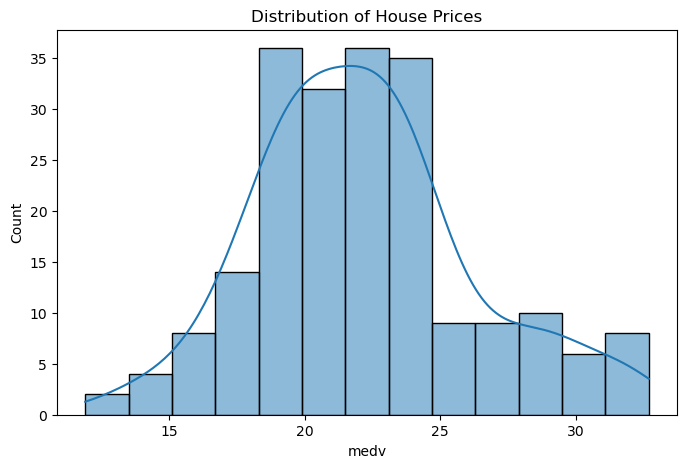

In [47]:
# Checking/visualisizing distribution of the dataframe.
plt.figure(figsize=(8,5))
sns.histplot(DF['medv'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

The data appears to be normally distributed from the generated graph above.

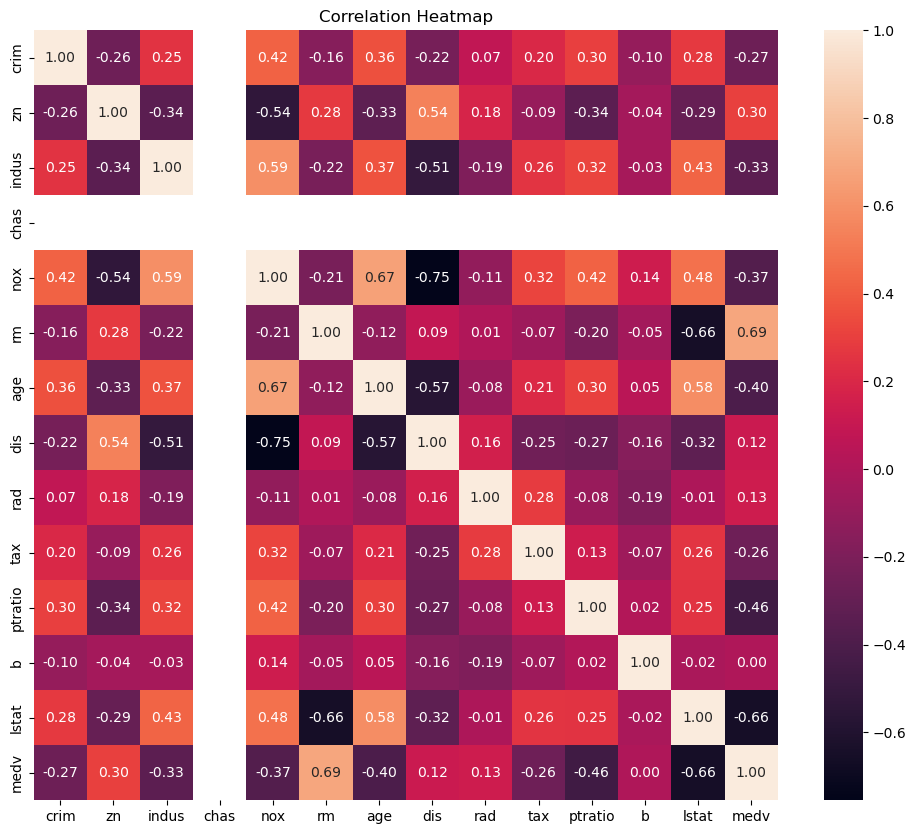

In [49]:
# Correlation hitmap, to check the correlation between multiple variables(columns)
plt.figure(figsize=(12,10))
sns.heatmap(DF.corr(), annot=True, cmap='rocket', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [50]:
# Check for variables that have high correlation with the target variable (medv). Such variables can be considered for modeling.
DF.corr()['medv'].sort_values(ascending=False)

medv       1.000000
rm         0.685914
zn         0.303391
rad        0.133322
dis        0.119875
b          0.002996
tax       -0.255125
crim      -0.266297
indus     -0.333543
nox       -0.374697
age       -0.403833
ptratio   -0.457803
lstat     -0.657595
chas            NaN
Name: medv, dtype: float64

rm and zn show a positive correlation.  
lstat and ptratio show negative correlation.  
The remaining variables do not show a strong correlation with the target variable.

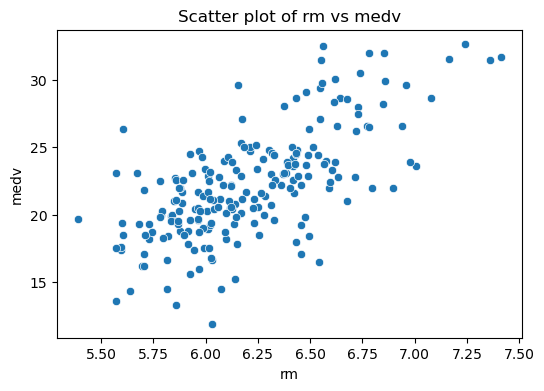

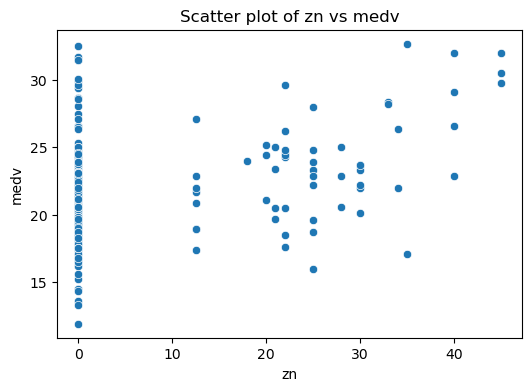

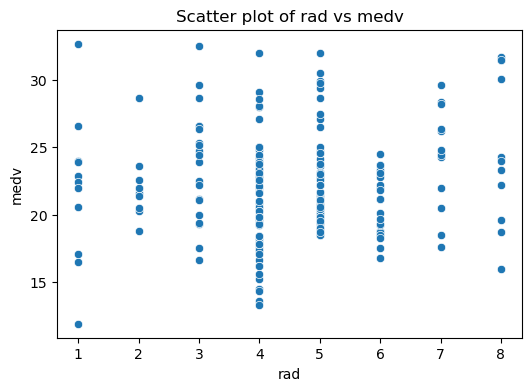

In [53]:
# Plotting scatter plot of the first three (3) positive correlated features with the target variable.
most_positive_correlated_features = DF.corr()['medv'].sort_values(ascending=False).index[1:]  # Exclude 'medv' itself
for feature in most_positive_correlated_features[:3]:  # Plot first 3 most correlated features
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=DF[feature], y=DF['medv'])
    plt.title(f"Scatter plot of {feature} vs medv")
    plt.xlabel(feature)
    plt.ylabel("medv")
    plt.show()

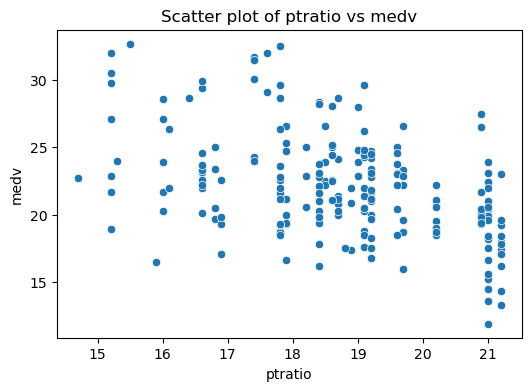

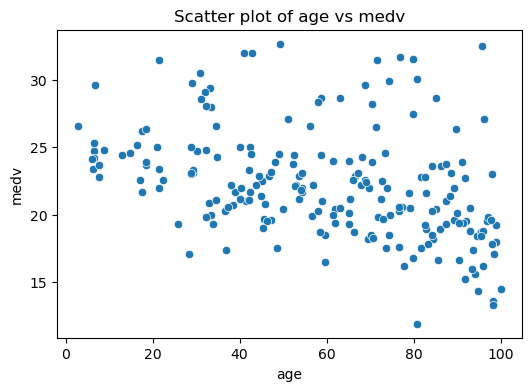

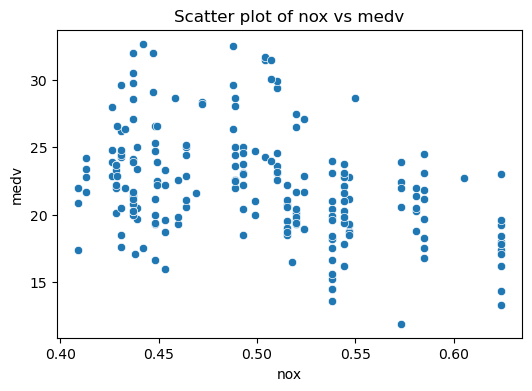

In [54]:
# Plotting scatter plot of the last three (3) positive correlated features with the target variable.
most_negative_correlated_features = DF.corr()['medv'].sort_values(ascending=True).index[1:]  # Exclude 'medv' itself
for feature in most_negative_correlated_features[:3]:  # Plot first 3 most correlated features
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=DF[feature], y=DF['medv'])
    plt.title(f"Scatter plot of {feature} vs medv")
    plt.xlabel(feature)
    plt.ylabel("medv")
    plt.show()

### Feature Selection

In [55]:
# From the dataframe, we extract our target variable other variables and store it separate.
X = DF.drop("medv", axis = 1)
y = DF["medv"]

Therefore, X represents the independent variables and y is the dependent variable which is our target variable; what we want to predict.

### Data Preprocessing

In [56]:
# Importing libraries used for preprocessing of data.
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [59]:
# Now, split data into train set and test set.
# Train set, is where the models will be trained and test set is where the model will predict the final results.
# Normally, the train set have more values.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Models

In [64]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
# 1. Linear Regression



lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 1.4649794067892832
RMSE: 1.838734950029479
R2 Score: 0.8132277483870263


In [66]:
# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression Results:
MAE: 1.4655718057278542
RMSE: 1.8358649181399618
R2 Score: 0.8138103489093961


In [67]:
# 3. Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

Lasso Regression Results:
MAE: 1.4705970988444155
RMSE: 1.8384131520515223
R2 Score: 0.8132931168878899


In [68]:
# 4. Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 1.5963571428571448
RMSE: 2.084484742773895
R2 Score: 0.759966679130699


In [69]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [70]:
# Evaluate tuned model
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score:", r2_score(y_test, y_pred_best))

Tuned Random Forest Results:
MAE: 1.6007261904761934
RMSE: 2.061223089575705
R2 Score: 0.7652940552670239


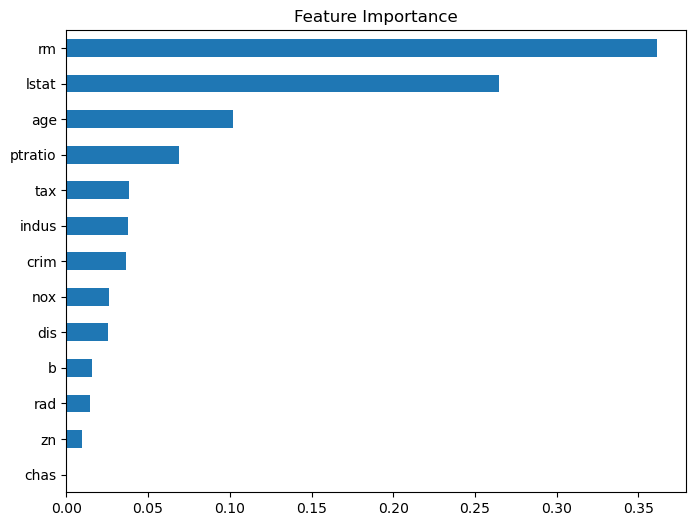

In [71]:
# Feature importance from the best Random Forest model
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [72]:
# Model comparison
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf)
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score
1,Ridge,0.813810
2,Lasso,0.813293
0,Linear,0.813228
3,Random Forest,0.759967


In [73]:
# Save the best model and scaler for future use
import joblib

joblib.dump(best_rf, "boston_house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']